# Install Required packages

In [1]:
!pip install torch torchvision scikit-learn numpy pandas joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 2.7 MB/s  0:00:27 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 4.2 MB/s  0:00:004.2 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 4.3 MB/s  0:00:004.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 4.5 MB/s  0:00:01m 4.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 2.5 MB/s  0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [torchvision] 6/7 [torchvision]]


# Creating csv file from features

In [1]:
import pandas as pd
import numpy as np

# Load preprocessed data
X_key = np.load('/Volumes/Dev/Project2/YogaPoseFusion/backend/data/processed/train_keypoints.npy')
X_spec = np.load('/Volumes/Dev/Project2/YogaPoseFusion/backend/data/processed/train_spectral.npy')
y = np.load('/Volumes/Dev/Project2/YogaPoseFusion/backend/data/processed/train_label_indices.npy')

# Combine (keypoints + spectral features)
X_combined = np.hstack([X_key, X_spec])

# Save to CSV
df = pd.DataFrame(X_combined)
df['label'] = y

csv_path = '/Volumes/Dev/Project2/YogaPoseFusion/backend/data/processed/pose_features_spectral.csv'
df.to_csv(csv_path, index=False)
print(f"✅ Saved with spectral features: {csv_path}")


✅ Saved with spectral features: /Volumes/Dev/Project2/YogaPoseFusion/backend/data/processed/pose_features_spectral.csv


# Model Training

✅ Device: mps
📁 Models will be saved in: /Volumes/Dev/Project2/YogaPoseFusion/backend/models

🔁 Training Fold 1/5
Fold 1 | Epoch [1/60] | Loss: 3.2945 | Val Acc: 0.5714
Fold 1 | Epoch [2/60] | Loss: 2.5699 | Val Acc: 0.6729
Fold 1 | Epoch [3/60] | Loss: 2.3545 | Val Acc: 0.7243
Fold 1 | Epoch [4/60] | Loss: 2.2156 | Val Acc: 0.7427
Fold 1 | Epoch [5/60] | Loss: 2.1297 | Val Acc: 0.7718
Fold 1 | Epoch [6/60] | Loss: 2.0482 | Val Acc: 0.7701
Fold 1 | Epoch [7/60] | Loss: 1.9674 | Val Acc: 0.7845
Fold 1 | Epoch [8/60] | Loss: 1.9131 | Val Acc: 0.7982
Fold 1 | Epoch [9/60] | Loss: 1.8851 | Val Acc: 0.8014
Fold 1 | Epoch [10/60] | Loss: 1.8648 | Val Acc: 0.8055
Fold 1 | Epoch [11/60] | Loss: 2.0385 | Val Acc: 0.7789
Fold 1 | Epoch [12/60] | Loss: 2.0237 | Val Acc: 0.7796
Fold 1 | Epoch [13/60] | Loss: 1.9882 | Val Acc: 0.7852
Fold 1 | Epoch [14/60] | Loss: 1.9546 | Val Acc: 0.7967
Fold 1 | Epoch [15/60] | Loss: 1.9071 | Val Acc: 0.7894
Fold 1 | Epoch [16/60] | Loss: 1.8739 | Val Acc: 0.8026

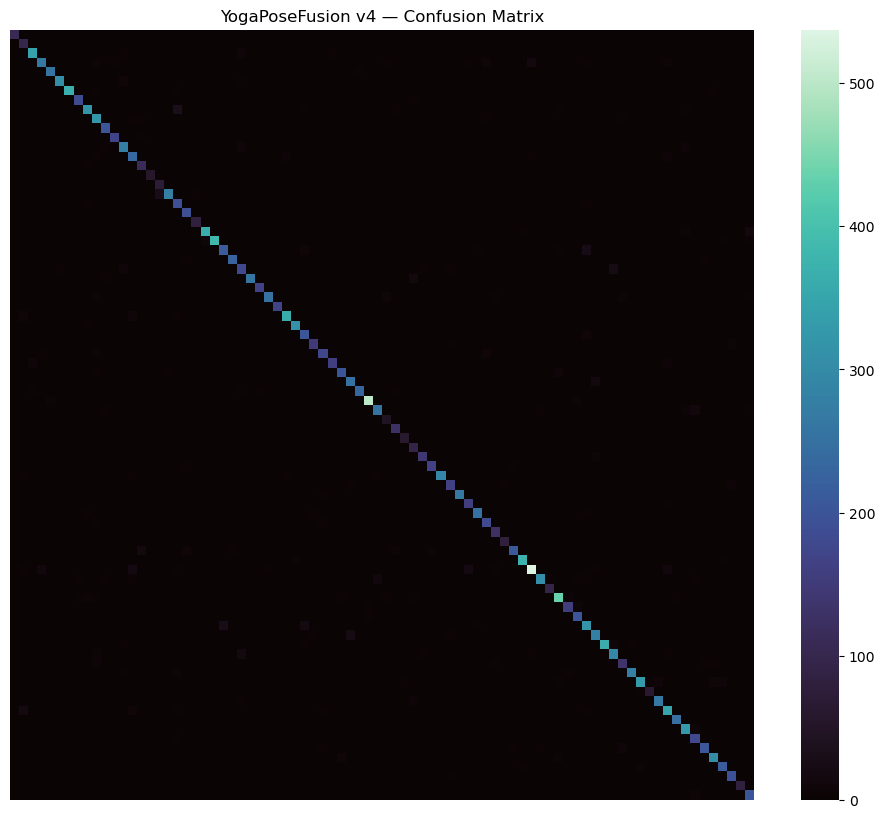

In [1]:
# ============================================================
# YogaPoseFusion v4 — High-Accuracy Model (M1 Optimized)
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ============================================================
# CONFIGURATION
# ============================================================
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")

DATA_PATH = "/Volumes/Dev/Project2/YogaPoseFusion/backend/data/processed/pose_features_spectral.csv"
MODEL_DIR = "/Volumes/Dev/Project2/YogaPoseFusion/backend/models"
os.makedirs(MODEL_DIR, exist_ok=True)

EPOCHS = 60
BATCH_SIZE = 32
LR = 1e-3
PATIENCE = 8
FOLDS = 5

print(f"✅ Device: {DEVICE}")
print(f"📁 Models will be saved in: {MODEL_DIR}")

# ============================================================
# DATASET
# ============================================================
class YogaPoseDataset(Dataset):
    def __init__(self, csv_path, augment=True):
        df = pd.read_csv(csv_path)
        self.X = df.drop(columns=["label"]).values
        self.y = df["label"].values
        self.scaler = StandardScaler()
        self.X = self.scaler.fit_transform(self.X)
        joblib.dump(self.scaler, os.path.join(MODEL_DIR, "scaler.pkl"))

        # Data augmentation
        if augment:
            noise = np.random.normal(0, 0.02, self.X.shape)
            self.X = np.vstack([self.X, np.clip(self.X + noise, -1, 1)])
            self.y = np.hstack([self.y, self.y])

        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ============================================================
# MODEL ARCHITECTURE — FusionNet v4
# ============================================================
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        return x + self.layer(x)

class YogaPoseFusionNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            ResidualBlock(1024),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            ResidualBlock(512),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# ============================================================
# TRAINING LOOP
# ============================================================
def train_one_fold(model, train_loader, val_loader, fold_idx, class_weights):
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

    best_acc = 0.0
    patience_counter = 0
    train_losses, val_accuracies = [], []

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
            running_loss += loss.item()

        scheduler.step()
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation
        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                preds = torch.argmax(model(X_batch), dim=1)
                y_true.extend(y_batch.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        acc = accuracy_score(y_true, y_pred)
        val_accuracies.append(acc)
        print(f"Fold {fold_idx+1} | Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_loss:.4f} | Val Acc: {acc:.4f}")

        # Early stopping
        if acc > best_acc:
            best_acc = acc
            patience_counter = 0
            model_path = os.path.join(MODEL_DIR, f"pose_classifier_v4_fold{fold_idx+1}.pt")
            torch.save(model.state_dict(), model_path)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("⏹ Early stopping.")
                break

    return best_acc

# ============================================================
# K-FOLD TRAINING
# ============================================================
def train_kfold(dataset):
    X, y = dataset.X.numpy(), dataset.y.numpy()
    num_classes = len(np.unique(y))
    class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

    kfold = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
    fold_accuracies = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
        print(f"\n==============================")
        print(f"🔁 Training Fold {fold+1}/{FOLDS}")
        print(f"==============================")

        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

        model = YogaPoseFusionNet(input_dim=X.shape[1], num_classes=num_classes).to(DEVICE)
        fold_acc = train_one_fold(model, train_loader, val_loader, fold, class_weights)
        fold_accuracies.append(fold_acc)
        torch.mps.empty_cache() if torch.backends.mps.is_available() else None

    avg_acc = np.mean(fold_accuracies)
    print(f"\n✅ Average K-Fold Validation Accuracy: {avg_acc:.4f}")
    return avg_acc

# ============================================================
# EVALUATION (ON TEST SET)
# ============================================================
def evaluate_final_model(model_path, dataset):
    model = YogaPoseFusionNet(input_dim=dataset.X.shape[1], num_classes=len(torch.unique(dataset.y)))
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    loader = DataLoader(dataset, batch_size=BATCH_SIZE)
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = torch.argmax(model(X_batch), dim=1)
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print("\n📊 Final Model Evaluation:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("Accuracy:", accuracy_score(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap="mako", xticklabels=False, yticklabels=False)
    plt.title("YogaPoseFusion v4 — Confusion Matrix")
    plt.show()

# ============================================================
# MAIN EXECUTION
# ============================================================
if __name__ == "__main__":
    dataset = YogaPoseDataset(DATA_PATH, augment=True)
    avg_acc = train_kfold(dataset)

    print(f"\n🚀 Training Complete | Avg Val Accuracy: {avg_acc:.4f}")
    best_model_path = os.path.join(MODEL_DIR, "pose_classifier_v4_fold1.pt")
    evaluate_final_model(best_model_path, dataset)
